In [3]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\HomePC\.conda\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df_DE_Canada = df[(df['job_title_short'] == 'Data Engineer') & (df['job_country'] == 'Canada')].copy()

df_DE_Canada = df_DE_Canada.dropna(subset=['salary_year_avg'])

In [5]:
df_DE_Canada

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
10270,Data Engineer,Lead Data Engineer - Hybrid,"Mississauga, ON, Canada",via Ladders,Full-time,False,Canada,2023-08-18 13:13:17,False,False,Canada,year,125000.0,NaN,"Citigroup, Inc","[golang, kotlin, scala, python, aws, azure, gc...","{'cloud': ['aws', 'azure', 'gcp'], 'libraries'..."
25962,Data Engineer,Data Engineer,"Toronto, ON, Canada",via EXL - Talentify,Full-time,False,Canada,2023-10-24 13:18:32,False,False,Canada,year,100000.0,NaN,ExlService,"[python, sql, aws, redshift, snowflake]","{'cloud': ['aws', 'redshift', 'snowflake'], 'p..."
35491,Data Engineer,Data Engineer ( Full Time) (CANADA),"Montreal, QC, Canada",via Dice.com,Full-time,False,Canada,2023-08-16 13:49:54,True,False,Canada,year,110000.0,NaN,Sierra Business Solution LLC,"[sql, c#, python, aws, redshift, pyspark, ssis]","{'analyst_tools': ['ssis'], 'cloud': ['aws', '..."
40698,Data Engineer,Data Engineer,"Markham, ON, Canada",via Ladders,Full-time,False,Canada,2023-12-14 06:11:41,False,False,Canada,year,101014.0,NaN,IBM,"[python, sql, watson, aws, ibm cloud, pyspark,...","{'cloud': ['watson', 'aws', 'ibm cloud'], 'lib..."
40840,Data Engineer,Data Engineering Analyst,"Mississauga, ON, Canada",via Ladders,Full-time,False,Canada,2023-03-10 06:28:02,False,False,Canada,year,90000.0,NaN,"Citigroup, Inc","[java, python]","{'programming': ['java', 'python']}"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
773144,Data Engineer,"Data Engineer, Investment Finance","Toronto, ON, Canada",via Ladders,Full-time,False,Canada,2023-02-27 01:10:49,False,False,Canada,year,90000.0,NaN,OMERS Administration Corporation,"[azure, snowflake, alteryx]","{'analyst_tools': ['alteryx'], 'cloud': ['azur..."
774654,Data Engineer,"Data Engineer, Marketing Technology","Toronto, ON, Canada",via Ai-Jobs.net,Full-time,False,Canada,2023-08-08 01:51:43,False,False,Canada,year,147500.0,NaN,Wayfair Inc.,"[python, java, mongodb, mongodb, cassandra, aw...","{'analyst_tools': ['looker', 'tableau'], 'clou..."
779787,Data Engineer,"Lead Data Engineer, Machine Learning Systems",Canada,via Ai-Jobs.net,Full-time,False,Canada,2023-01-31 05:17:45,False,False,Canada,year,147500.0,NaN,Course Hero,"[python, sql, aws, databricks, spark, airflow,...","{'cloud': ['aws', 'databricks'], 'libraries': ..."
782475,Data Engineer,Data Platform Engineer,"Toronto, ON, Canada",via Ladders,Full-time,False,Canada,2023-01-17 06:55:23,False,False,Canada,year,125000.0,NaN,Sanofi,"[sql, python, azure, gcp, snowflake, aws, airf...","{'cloud': ['azure', 'gcp', 'snowflake', 'aws']..."


In [6]:
df_DE_Canada = df_DE_Canada.explode('job_skills')

df_DE_Canada['job_skills']

10270      golang
10270      kotlin
10270       scala
10270      python
10270         aws
           ...   
783881     oracle
783881     hadoop
783881      spark
783881      kafka
783881    windows
Name: job_skills, Length: 1303, dtype: str

In [7]:
df_DE_Canada_group = df_DE_Canada.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])

df_DE_top_pay = df_DE_Canada_group.sort_values(by='median', ascending=False).head(10)

df_DE_skills = df_DE_Canada_group.sort_values(by='count', ascending=False).head(10).sort_values(by='median', ascending=False)

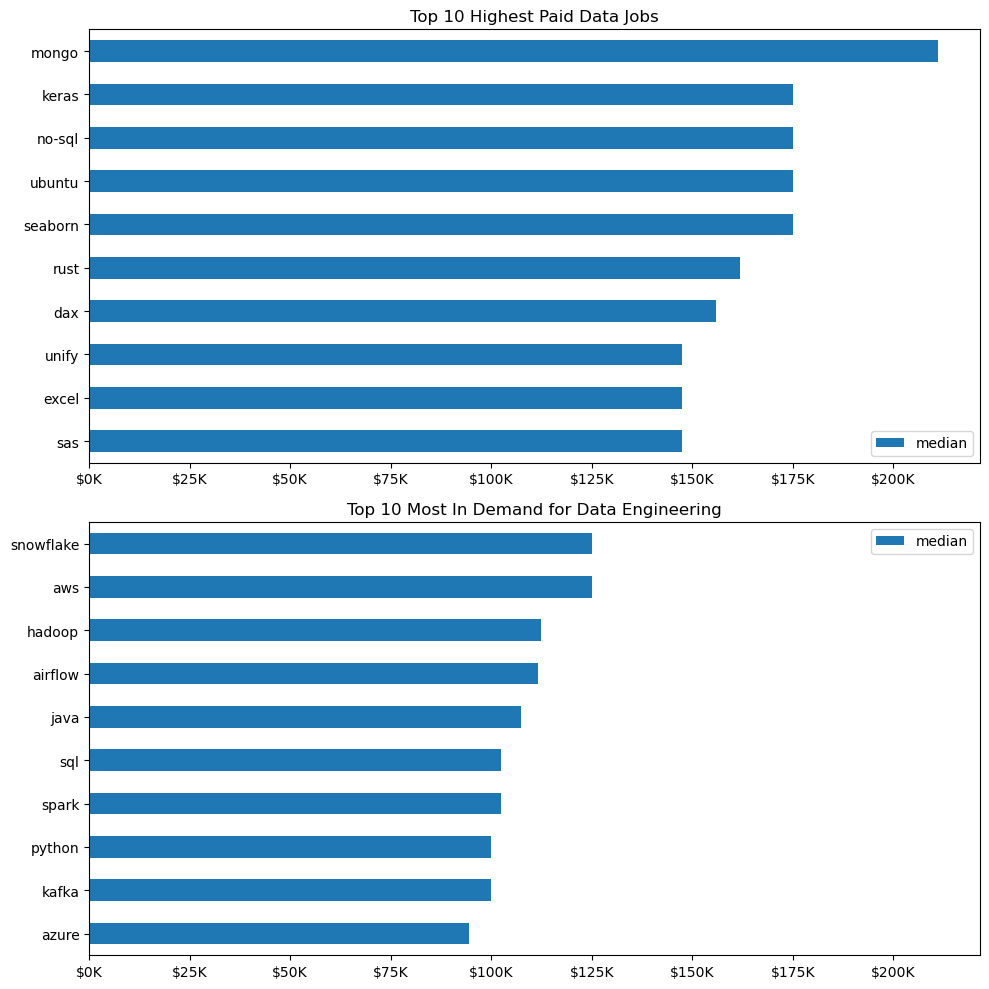

In [16]:
fig, ax = plt.subplots(2, 1, figsize=(10, 10))

df_DE_top_pay[::-1].plot(kind='barh', y='median', ax=ax[0])
ax[0].set_title('Top 10 Highest Paid Data Jobs')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))  # ✅

df_DE_skills[::-1].plot(kind='barh', y='median', ax=ax[1])
ax[1].set_title('Top 10 Most In Demand for Data Engineering')
ax[1].set_ylabel('')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))  # ✅

plt.tight_layout()
plt.show()